# 03 · Level-1 merged analyzers: full-year figures

The merged full-year view of the **Level-1 EddyPro fluxes**, before the flux
processing chain (no L2 quality flags, no storage term, no outlier removal, no
USTAR filtering). It is the pre-quality-control counterpart of
[notebook 08](08_merged_analyzers_full_year.ipynb): what the raw flux and the time
lag look like straight out of EddyPro, on every reported half hour.

This notebook only draws figures. The merging happened in
[notebook 02](02_level1_merged_analyzers.ipynb), and its single output table is the
only input read here, so nothing is loaded from the Level-1 tables a second time.

Two figures are produced, one per gas:

- **N2O:** the five variants as columns, each a merged full-year series, with the
  raw flux (top), the merged time lag used (middle), and a histogram of that lag
  with its mode highlighted (bottom). Saved as `figures/03_merged_n2o.png`.
- **CH4:** the same, for methane. Saved as `figures/03_merged_ch4.png`.

The same merged table is read a second way, along the time lag instead of along
time, in the supplement
[SUPPL · Level-1 time-lag diagnostics](SUPPL_level1_lag_diagnostics.ipynb).

Input:
- `data/02-level1_merged_parquet/level1_merged.parquet` (notebook 02).

## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from diive.core.io.files import load_parquet

# White figure background (on screen and in saved PNGs).
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

The five variants are the columns; each column is the QCL half and the LGR half of
that variant, already merged into one full-year series by notebook 02. The lag for
variants `*-1` to `*-4` is the EddyPro time lag used, while the PWB$_{OPT}$ column
(`*-5`) carries its optimised lag (the PWB estimate after the S1/S2/S3 decision
rule). The constant-lag variant (`*-4`) carries two constants here, one per
campaign, so its histogram row shows a single filled bin at each constant rather
than a spread.

The column-name helpers (`flux_col`, `lag_col`) mirror the ones notebook 02 wrote
the table with.

Method abbreviations follow Vitale et al. (2024): CM = covariance maximisation,
CM$_{CTR}$ = constrained CM (narrow window), PWB$_{OPT}$ = optimised
pre-whitening with block-bootstrap.

In [2]:
MERGEDFILE = Path("../data/02-level1_merged_parquet/level1_merged.parquet")
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

FIGSIZE = (16, 9)
DPI = 300

# Font sizes, kept in one place. Larger than the matplotlib defaults so the
# figures stay readable when scaled down to manuscript column width.
FS_TICK = 13    # tick labels
FS_LABEL = 15   # axis labels
FS_TITLE = 16   # column titles (the variant names)
FS_PANEL = 15   # panel letters (a), (b), ...
FS_ANNOT = 13   # in-panel text (modal lag) and the legend
plt.rcParams.update({
    "font.size": FS_TICK,
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_TITLE,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
})

# The two analyzers cover complementary halves of the year; QCL is the earlier
# campaign (plotted first), LGR the later one.
ANALYZERS = ["QCL", "LGR"]
# Columns = the five time-lag variants; each is already merged across both analyzers.
VARIANTS = [1, 2, 3, 4, 5]
PWB_VARIANT = 5  # the PWB variant carries its detected lag, not the EddyPro lag

# Column titles describe each variant's time-lag method (see
# docs/time-lag.qmd). CM-W = covariance maximisation of the gas against
# the vertical wind speed w (0 to 10 s search window, |cov| max criterion). The
# upright DEF superscript marks the fallback to the nominal/default lag when the
# peak search fails (variants *-2 and *-3); the CTR superscript marks the
# constrained (narrow-window) CM (variant *-3). PWB^OPT is the optimised
# pre-whitening lag (S1/S2/S3 decision rule applied to the PWB estimates). These
# map to the Vitale et al. (2024) abbreviations CM, CM_CTR and PWB_OPT.
VARIANT_NAMES = {
    1: "|cov| max, wide",
    2: r"|cov| max, wide, default",
    3: r"|cov| max, narrow, default",
    4: "Constant time lag",
    5: r"PWB$^{\mathrm{OPT}}$",
}

# Per gas: the merged flux variable and the merged time-lag variable, i.e. the
# stems notebook 02 built its column names from.
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED"},
}


def flux_col(gas, var):
    """Merged flux column name, e.g. ('N2O', 3) -> 'FN2O_V3'."""
    return f"{GASES[gas]['flux']}_V{var}"


def lag_col(gas, var):
    """Merged time-lag column name, e.g. ('N2O', 3) -> 'N2O_TLAG_USED_V3'."""
    return f"{GASES[gas]['lag']}_V{var}"


# One color per instrument, used across all three rows (flux, lag, histogram).
# Distinct but from neighbouring hues, so the figure stays cohesive.
INSTRUMENT_COLORS = {"QCL": "#3182bd", "LGR": "#e67e22"}  # blue, orange

# Pretty gas labels for axis text and titles.
GAS_LABEL = {"N2O": "N$_2$O", "CH4": "CH$_4$"}

BIN_S = 0.05                 # tlag raster (s); the mode is snapped to this grid
PCTL = (1, 99)               # robust flux y-range percentiles
SEARCH_WINDOW = (0.0, 10.0)  # covariance-maximization search window (s)
FRINGE_MARGIN = 0.1          # peak search ignores lags within this of the rails

print(f"Plotting merged full-year series (Level-1 raw fluxes) from {MERGEDFILE.name}")

Plotting merged full-year series (Level-1 raw fluxes) from level1_merged.parquet


## Load the merged table

One file, written by notebook 02: the merged full-year raw flux and time lag per
variant and gas, plus the `ANALYZER` column. The instrument column is what splits
each merged series back into its QCL and its LGR half for the per-instrument
colors, histograms and modes, and it also places the campaign handover line.

In [3]:
merged = load_parquet(filepath=str(MERGEDFILE))

# Per-instrument views of the merged series (the campaigns do not overlap, so
# masking on ANALYZER is an exact split), keyed by (analyzer, variant, gas).
is_analyzer = {a: merged["ANALYZER"] == a for a in ANALYZERS}
rawflux, lag_used = {}, {}
# The merged full-year series themselves, keyed by (variant, gas).
merged_flux, merged_lag = {}, {}

for var in VARIANTS:
    for gas in GASES:
        flux = merged[flux_col(gas, var)]
        lag = merged[lag_col(gas, var)]
        merged_flux[(var, gas)] = flux
        merged_lag[(var, gas)] = lag
        for a in ANALYZERS:
            rawflux[(a, var, gas)] = flux.where(is_analyzer[a])
            lag_used[(a, var, gas)] = lag.where(is_analyzer[a])

# Campaign handover: midpoint between the last QCL and the first LGR timestamp.
_qcl_end = merged.index[is_analyzer["QCL"]].max()
_lgr_start = merged.index[is_analyzer["LGR"]].min()
HANDOVER = _qcl_end + (_lgr_start - _qcl_end) / 2

for var in VARIANTS:
    s = merged_flux[(var, "N2O")]
    print(f"variant -{var}: {int(s.notna().sum())} valid merged raw N2O "
          f"({s.index.min():%Y-%m-%d} to {s.index.max():%Y-%m-%d})")
print(f"campaign handover marked at {HANDOVER:%Y-%m-%d %H:%M}")

> Loaded .parquet file ..\data\02-level1_merged_parquet\level1_merged.parquet (0.042 seconds).

variant -1: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -2: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -3: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -4: 17181 valid merged raw N2O (2021-01-01 to 2021-12-31)
variant -5: 17182 valid merged raw N2O (2021-01-01 to 2021-12-31)
campaign handover marked at 2021-07-21 13:15


## Figures: merged full-year raw flux, time lag, lag histogram

One figure per gas. Three rows (raw flux over time, time lag used over time, lag
histogram) with the five variants as columns. The two instruments carry one
color each (QCL blue, LGR yellow-orange), used consistently across all three rows;
the top-left flux panel carries the instrument legend, and a light dashed line
marks the QCL to LGR handover in the top two rows.

The bottom row overlays the two instruments' lag histograms, binned on the EddyPro
tlag raster (0.05 s bins, one bar per reported lag value), drawn with time lag on
the vertical axis and count on the horizontal axis, so it reads as a rotated
histogram aligned with the lag row above it. The two instruments' bars are
overlaid (not stacked) and semi-transparent, so both stay visible where they
overlap. Within each row the y-axis is shared across the columns (only the first
column shows y tick labels): flux, time lag, and also the histogram row's
time-lag axis. The shared count axis is scaled to the PWB$_{OPT}$ variant's tallest
bar, so every column is read against the PWB method's peak count; the more
concentrated variants (the narrow-window CM, and the single-bin constant lag) have
taller bars that run past the right edge. Each instrument's modal lag is printed in
the upper-right corner of the panel, coloured by instrument (`Mode QCL` above,
`Mode LGR` below). The mode is the peak 0.05 s bin of the non-fringe lags, so it
lands on the grid (e.g. 0.65 s) and the 0 s / 10 s search window rails (mostly
`*-1`) cannot be mistaken for it. The constant-lag variant (`*-4`) is single-valued
per campaign, so its whole record falls into one 0.05 s bin (that bar overshoots
the count axis and reaches the right edge).

Saved ..\figures\03_merged_n2o.png


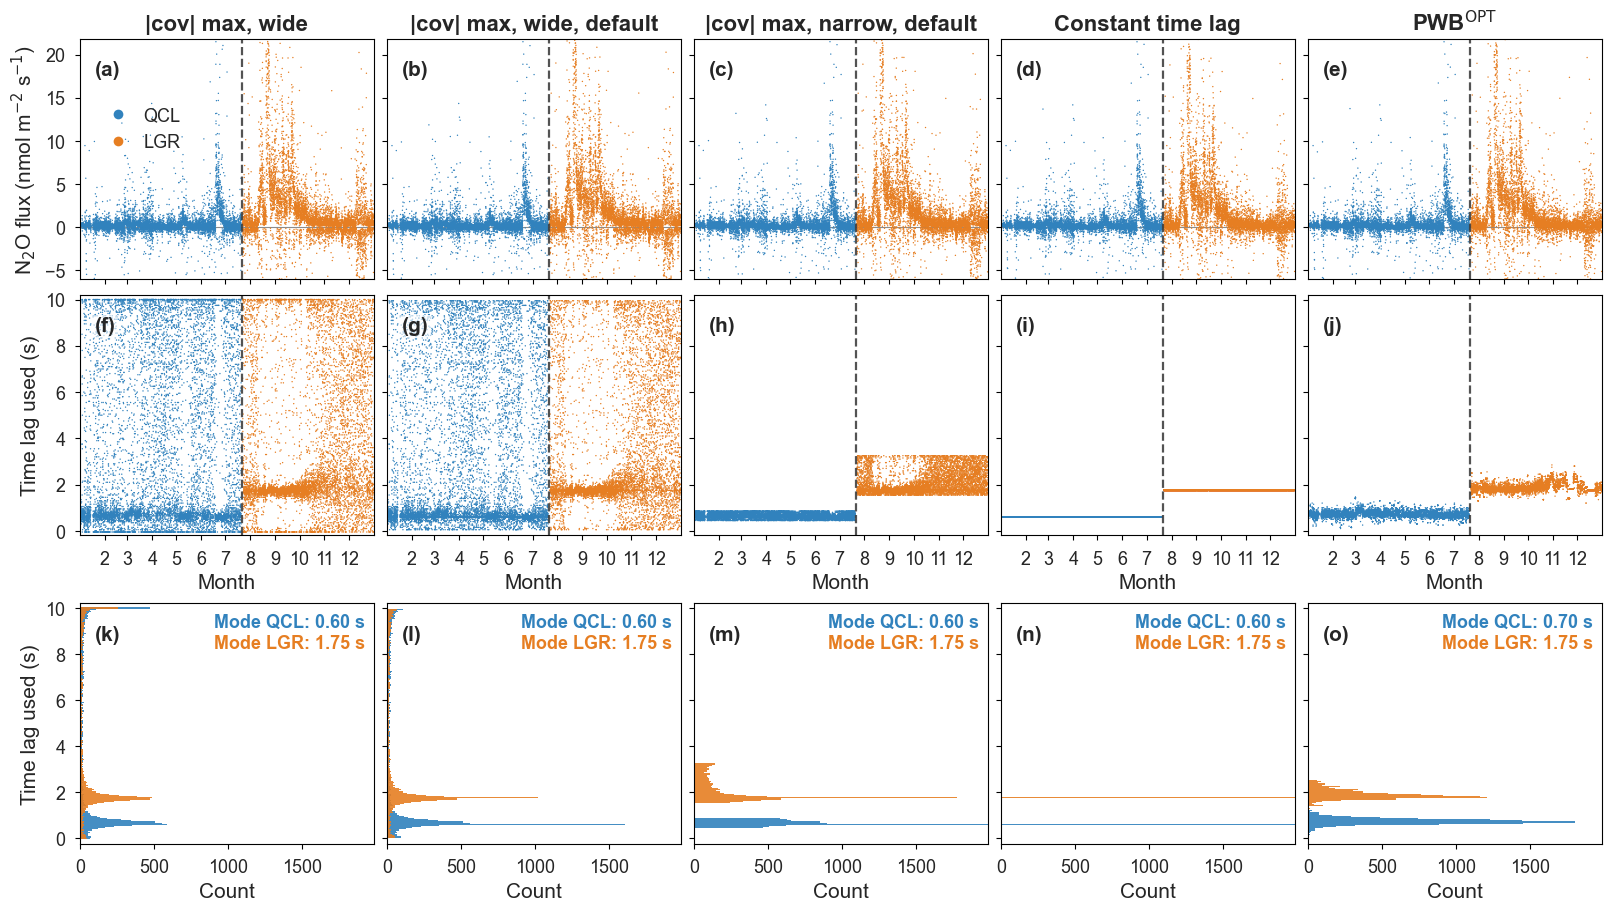

Saved ..\figures\03_merged_ch4.png


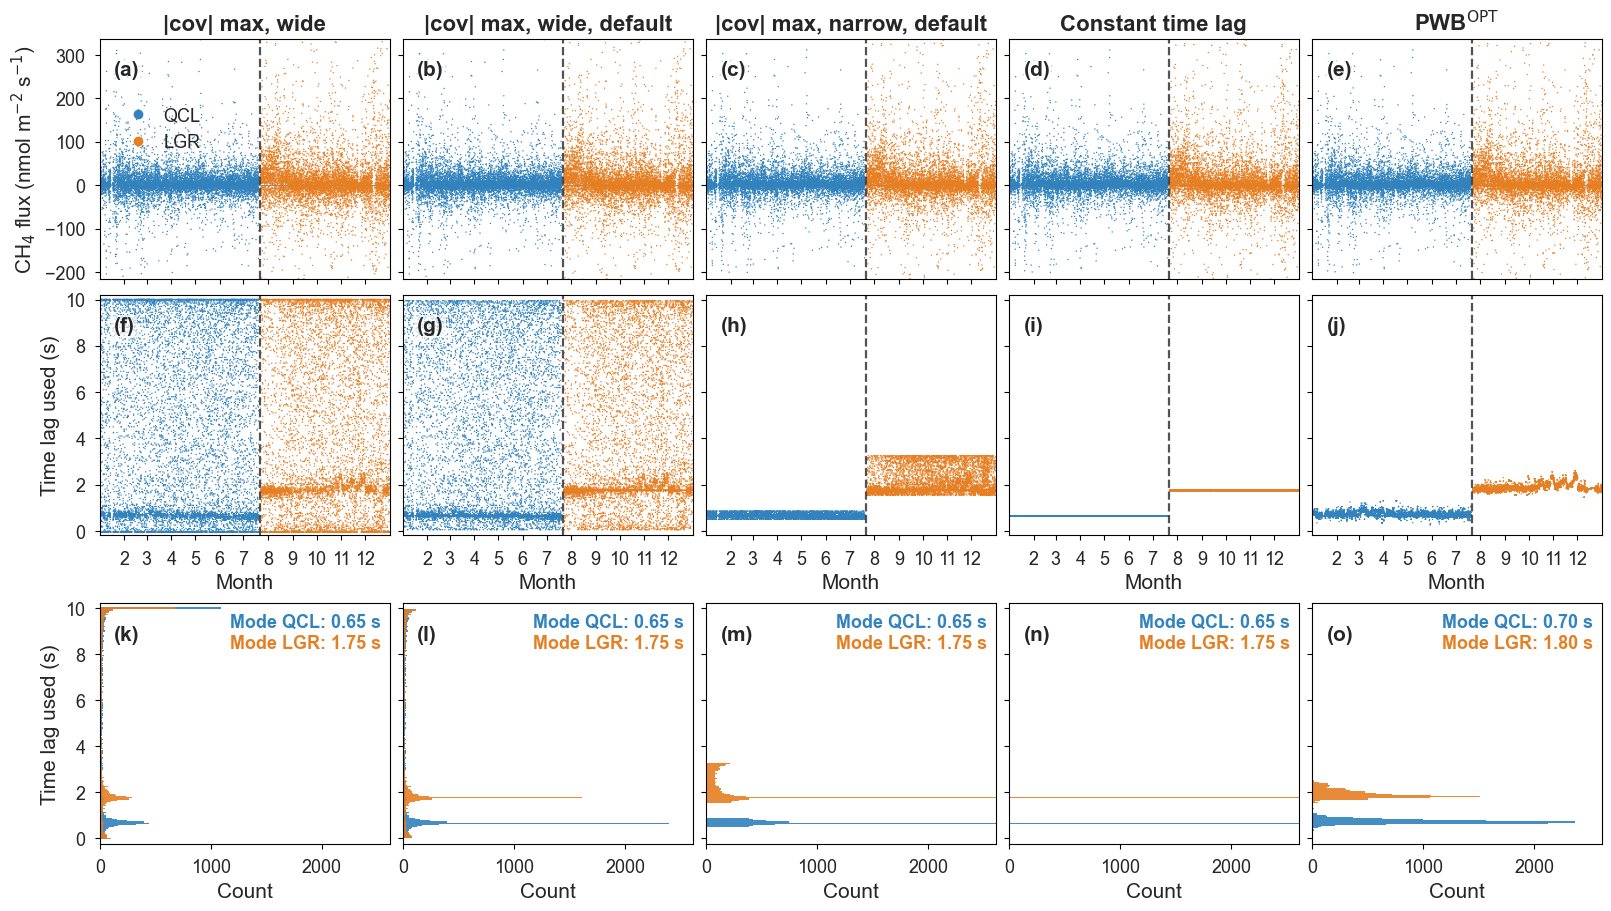

In [4]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


LAG_YLIM = (-0.2, 10.2)  # full 0 to 10 s search window with a small pad
LO_EDGE = SEARCH_WINDOW[0] + FRINGE_MARGIN
HI_EDGE = SEARCH_WINDOW[1] - FRINGE_MARGIN
MARKER_S = 1       # scatter marker size for the flux and lag rows
LETTERS = "abcdefghijklmnopqrstuvwxyz"
# Histogram bins match the EddyPro tlag raster (BIN_S = 0.05 s) and are centred on
# the raster multiples, so each bar sits exactly on a reported lag value.
HIST_EDGES = np.arange(SEARCH_WINDOW[0] - BIN_S / 2, SEARCH_WINDOW[1] + BIN_S, BIN_S)
HIST_CENTERS = 0.5 * (HIST_EDGES[:-1] + HIST_EDGES[1:])  # bar centres on the lag axis
# Upper-right corner rows for the two instruments' modal-lag labels (axes fraction).
LABEL_YFRAC = (0.96, 0.87)


def month_int(x, pos):
    """Format a date tick as its (integer) month number, no year."""
    return f"{mdates.num2date(x).month}"


def panel_letter(ax, text):
    """Bold panel letter in the top-left corner, over a faint white patch."""
    ax.text(0.05, 0.91, f"({text})", transform=ax.transAxes, va="top", ha="left",
            fontsize=FS_PANEL, fontweight="bold",
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.6))


def style_axes(ax):
    """Black spines, short outward major/minor ticks, no grid."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(which="major", length=3.5, width=0.8, direction="out", color="black")
    ax.tick_params(which="minor", length=2.0, width=0.6, direction="out", color="black")


def lag_counts(values):
    """Histogram counts of a lag series on the fixed HIST_EDGES (0.05 s raster).
    The constant-lag variant is single-valued, so it lands entirely in one bin
    (that bar overshoots the PWB-scaled count axis and reaches the right edge).
    Returns None only for an empty or too-short series."""
    v = np.asarray(pd.Series(values).dropna(), dtype=float)
    if v.size < 5:
        return None
    return np.histogram(v, bins=HIST_EDGES)[0]


def mode_on_grid(values):
    """Modal lag snapped to the BIN_S (0.05 s) tlag raster: the peak 0.05 s bin of
    the non-fringe lags (so the 0 s / 10 s rails cannot be the mode), e.g. 0.65 s.
    Matches how EddyPro reports the lag, so the reported value sits on the grid
    rather than on the finer histogram axis. Returns None if no non-fringe lag
    exists."""
    s = pd.Series(values).dropna()
    s = s[(s > LO_EDGE) & (s < HI_EDGE)]
    if s.empty:
        return None
    lo_k = int(np.floor(s.min() / BIN_S))
    hi_k = int(np.ceil(s.max() / BIN_S))
    edges = (np.arange(lo_k, hi_k + 2) - 0.5) * BIN_S  # bins centred on k * BIN_S
    counts, _ = np.histogram(s, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return float(centers[int(np.argmax(counts))])


# Legend proxies for the two instruments (shown in the top-left flux panel).
inst_handles = [Line2D([0], [0], marker="o", linestyle="", markersize=7,
                       color=INSTRUMENT_COLORS[a], label=a) for a in ANALYZERS]

for gas in GASES:
    columns = VARIANTS
    ncols = len(columns)
    glabel = GAS_LABEL[gas]

    # Flux y-range across both instruments and all variants. For N2O the upper
    # limit is the 99.5th percentile, high enough to show most of the tall N2O
    # peaks while clipping the few extreme outliers that would otherwise squash the
    # bulk of the data; the lower limit keeps the robust 1st percentile. CH4 uses
    # the symmetric robust range.
    flux_vals = np.concatenate(
        [merged_flux[(var, gas)].to_numpy().ravel() for var in columns])
    if gas == "N2O":
        lo, hi = np.nanpercentile(flux_vals, (PCTL[0], 99.5))
        pad = 0.05 * (hi - lo)
        flux_ylim = (lo - pad, hi + pad)
    else:
        flux_ylim = robust_ylim(flux_vals)

    # Common lag range for the histogram row (data-driven, shared across columns).
    # The histogram row plots time lag on the vertical axis, so this is its y-range.
    all_lag = np.concatenate(
        [lag_used[(a, var, gas)].dropna().to_numpy()
         for var in columns for a in ANALYZERS])
    lag_range = (float(np.nanmin(all_lag)) - 0.2, float(np.nanmax(all_lag)) + 0.2)

    # Pre-compute each column/instrument lag histogram (bin counts) and its
    # raster-snapped mode.
    hist_cache = {}
    for var in columns:
        for a in ANALYZERS:
            counts = lag_counts(lag_used[(a, var, gas)])
            m = mode_on_grid(lag_used[(a, var, gas)])
            hist_cache[(var, a)] = (counts, m)

    # Scale the shared count axis to the PWB_OPT variant's tallest bar, so every
    # column is read against the PWB method's peak count. Taller bars from the more
    # concentrated variants (the narrow-window CM, and the single-bin constant lag)
    # run past the right edge.
    count_max = max(
        (float(hist_cache[(PWB_VARIANT, a)][0].max())
         for a in ANALYZERS if hist_cache[(PWB_VARIANT, a)][0] is not None),
        default=1.0)
    count_xlim = (0, count_max * 1.1)

    fig, axes = plt.subplots(nrows=3, ncols=ncols,
                             figsize=FIGSIZE, constrained_layout=True)

    for ci, var in enumerate(columns):
        ax_flux, ax_lag, ax_hist = axes[0, ci], axes[1, ci], axes[2, ci]

        ax_lag.sharex(ax_flux)
        # Within each row the y-axis is shared across columns; only the first
        # column keeps its y tick labels.
        if ci > 0:
            ax_flux.sharey(axes[0, 0])
            ax_lag.sharey(axes[1, 0])
            ax_hist.sharey(axes[2, 0])
            for ax in (ax_flux, ax_lag, ax_hist):
                ax.tick_params(labelleft=False)
        for r, ax in enumerate((ax_flux, ax_lag, ax_hist)):
            style_axes(ax)
            panel_letter(ax, LETTERS[r * ncols + ci])
        ax_flux.set_title(VARIANT_NAMES[var], fontweight="bold", fontsize=FS_TITLE)

        # Rows 1 and 2: raw flux and time lag over time, one color per instrument.
        ax_flux.axhline(0, color="0.55", lw=0.8, zorder=0.5)  # zero reference
        for a in ANALYZERS:
            c = INSTRUMENT_COLORS[a]
            f = rawflux[(a, var, gas)].dropna()
            ax_flux.scatter(f.index, f, s=MARKER_S, alpha=1, color=c, edgecolors="none")
            lg = lag_used[(a, var, gas)].dropna()
            ax_lag.scatter(lg.index, lg, s=MARKER_S, alpha=1, color=c, edgecolors="none")
        for ax in (ax_flux, ax_lag):
            ax.axvline(HANDOVER, color="0.25", lw=1.6, ls="--", alpha=0.9)
        ax_flux.set_ylim(flux_ylim)
        if gas == "N2O":
            # Flux tick labels in steps of 5 on the top row for N2O.
            ax_flux.yaxis.set_major_locator(mticker.MultipleLocator(5))
        ax_flux.tick_params(labelbottom=False)
        ax_lag.set_ylim(*LAG_YLIM)
        # Time axis: every month is a major tick, labelled with its integer month
        # number 2 to 12 (no year); no minor ticks. A "Month" axis label.
        ax_lag.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax_lag.xaxis.set_major_formatter(mticker.FuncFormatter(month_int))
        ax_lag.xaxis.set_minor_locator(mticker.NullLocator())
        ax_lag.set_xlabel("Month")
        span = merged_lag[(var, gas)].index
        ax_lag.set_xlim(span.min(), span.max())

        # Row 3: lag histogram (bin counts) per instrument, time lag on the vertical
        # axis and count on the horizontal axis (a rotated histogram aligned with
        # the lag row above). The two instruments' bars are overlaid (not stacked)
        # and semi-transparent so both stay visible where they overlap. Each
        # instrument's modal lag (peak 0.05 s bin, EddyPro tlag raster) is printed in
        # the upper-right corner, coloured by instrument. The constant-lag variant is
        # single-valued, so its whole record falls in one 0.05 s bin whose bar
        # overshoots the PWB-scaled count axis and reaches the right edge.
        for i, a in enumerate(ANALYZERS):
            c = INSTRUMENT_COLORS[a]
            counts, m = hist_cache[(var, a)]
            if counts is not None:
                ax_hist.barh(HIST_CENTERS, counts, height=BIN_S, color=c,
                             alpha=0.9, align="center", linewidth=0, zorder=1)
            if m is None:
                continue
            # Modal lag printed in the upper-right corner, coloured by instrument.
            ax_hist.text(0.97, LABEL_YFRAC[i], f"Mode {a}: {m:.2f} s",
                         transform=ax_hist.transAxes, ha="right", va="top",
                         fontsize=FS_ANNOT, fontweight="bold", color=c, zorder=6)
        ax_hist.set_xlim(*count_xlim)
        ax_hist.set_xlabel("Count")

    # Shared time-lag axis for the bottom (histogram) row (set once; sharey propagates).
    axes[2, 0].set_ylim(*lag_range)

    axes[0, 0].set_ylabel(f"{glabel} flux (nmol m$^{{-2}}$ s$^{{-1}}$)")
    axes[1, 0].set_ylabel("Time lag used (s)")
    axes[2, 0].set_ylabel("Time lag used (s)")
    axes[0, 0].legend(handles=inst_handles, loc="upper left",
                      bbox_to_anchor=(0.02, 0.78), fontsize=FS_ANNOT, framealpha=0.9,
                      handletextpad=0.4, borderpad=0.3)

    out = FIGDIR / f"03_merged_{gas.lower()}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

**Figure.** Level-1 (pre-quality-control) merged full-year 2021 series, one
figure per gas (N₂O first, then CH₄), with the five time-lag variants as
columns. Rows: the merged raw flux (top), the time lag used (middle), and the
per-instrument lag histogram (bottom). The dashed line marks the QCL to LGR
handover, and each histogram panel prints the two instruments' modal lags.
Saved as `figures/03_merged_{gas}.png`.

## Runtime

In [5]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-07-24 15:18:12
End:      2026-07-24 15:18:29
Runtime:  0:00:16.664307
